In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [2]:
"""
Self-contained module: all auxiliary functions (wavelengths r and b),
the v2-isolated splits, and the contraction maps H_1, H_2, H_3.

Only dependency: numpy. No local module imports -- everything is in this file,
using the same function bodies translated previously.

Input convention (same as before):
    array = [t, u, v]
    t   = array[0]          (scalar)
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]

Vector-valued maps return numpy arrays of shape (2,).
The H maps take two such arrays: I_r = [t_r, u_r, v_r], I_b = [t_b, u_b, v_b].
"""
# ---------------------------------------------------------------------------
# Parameters -- set these to your problem's values
# ---------------------------------------------------------------------------
# n_r = 1.5143      # refractive index for wavelength r, must satisfy n_r > 1
# n_b = 1.5224      # refractive index for wavelength b, must satisfy n_b > 1
# rho_0 = 1    # rho_0 > 0
# d_0 = 2*10**(5)      # d_0 > 0
# k_0 = rho_0 / d_0
# w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)
n_r = 1.1400     # refractive index for wavelength r, must satisfy n_r > 1
n_b = 1.8660      # refractive index for wavelength b, must satisfy n_b > 1
rho_0 = 1    # rho_0 > 0
d_0 = 2     # d_0 > 0
k_0 = rho_0 / d_0
w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)

def _unpack(array):
    """Split the input array into t, u_1, u_2, v_1, v_2."""
    t = array[0]
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]
    return t, u_1, u_2, v_1, v_2


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH r FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha(array):
    """alpha(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_r**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_r(array):
    """
    M_r(t,u) = (1/n_r) [ (sin t, cos t)
                         - alpha(u) (u_1 sin t - u_2 cos t,
                                     u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_r


def D_r(array):
    """D_r(t,u) = ((n_r-1) d_0 - u_1 (1 - cos t)) / (n_r - w . M_r(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mr = M_r(array)
    numerator = (n_r - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_r - np.dot(w, Mr)
    return numerator / denominator


def F_r(array):
    """F_r(t,u) = u_1 (sin t, cos t) + D_r(t,u) M_r(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_r(array) * M_r(array)


def Lambda_2r(array):
    """Lambda_{2,r}(t,u) = sqrt(1 + 1/n_r^2 - (2/n_r) w . M_r(t,u))."""
    Mr = M_r(array)
    return np.sqrt(1.0 + 1.0 / n_r**2 - (2.0 / n_r) * np.dot(w, Mr))


def alpha_tilde(array):
    """
    alpha_tilde(u,v) = (n_r^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_r^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_r**2 - 1) + u_1 * v_1) / root
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_r_tilde(array):
    """
    M_r_tilde(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                    (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_t = alpha_tilde(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_r


def D_r_tilde(array):
    """
    D_r_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
          + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde) ]
        / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mr_t = np.dot(w, M_r_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mr_t)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde(array):
    """
    F_r_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde(t,u,v) D_r(t,u) + M_r(t,u) D_r_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_r_tilde(array) * D_r(array) + M_r(array) * D_r_tilde(array)


def Lambda_2r_tilde(array):
    """Lambda_2r_tilde(t,u,v) = -(1/n_r) (w . M_r_tilde) / Lambda_2r(t,u)."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH b FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha_b(array):
    """alpha_b(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_b**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_b(array):
    """
    M_b(t,u) = (1/n_b) [ (sin t, cos t)
                         - alpha_b(u) (u_1 sin t - u_2 cos t,
                                       u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_b


def D_b(array):
    """D_b(t,u) = ((n_b-1) d_0 - u_1 (1 - cos t)) / (n_b - w . M_b(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mb = M_b(array)
    numerator = (n_b - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_b - np.dot(w, Mb)
    return numerator / denominator


def F_b(array):
    """F_b(t,u) = u_1 (sin t, cos t) + D_b(t,u) M_b(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_b(array) * M_b(array)


def Lambda_2b(array):
    """Lambda_{2,b}(t,u) = sqrt(1 + 1/n_b^2 - (2/n_b) w . M_b(t,u))."""
    Mb = M_b(array)
    return np.sqrt(1.0 + 1.0 / n_b**2 - (2.0 / n_b) * np.dot(w, Mb))


def alpha_tilde_b(array):
    """
    alpha_tilde_b(u,v) = (n_b^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_b^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_b**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_b**2 - 1) + u_1 * v_1) / root
    return (n_b**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_b_tilde(array):
    """
    M_b_tilde(t,u,v) = (1/n_b) [ (cos t, -sin t)
        - alpha_tilde_b(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha_b(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                      (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    a_t = alpha_tilde_b(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_b


def D_b_tilde(array):
    """
    D_b_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_b - w . M_b)
          + ((n_b-1) d_0 - u_1 (1 - cos t)) (w . M_b_tilde) ]
        / (n_b - w . M_b)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mb = np.dot(w, M_b(array))
    w_dot_Mb_t = np.dot(w, M_b_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_b - w_dot_Mb)
                 + ((n_b - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mb_t)
    return numerator / (n_b - w_dot_Mb)**2


def F_b_tilde(array):
    """
    F_b_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_b_tilde(t,u,v) D_b(t,u) + M_b(t,u) D_b_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_b_tilde(array) * D_b(array) + M_b(array) * D_b_tilde(array)


def Lambda_2b_tilde(array):
    """Lambda_2b_tilde(t,u,v) = -(1/n_b) (w . M_b_tilde) / Lambda_2b(t,u)."""
    return -(1.0 / n_b) * np.dot(w, M_b_tilde(array)) / Lambda_2b(array)


# ===========================================================================
# ===========================================================================
#         v2-ISOLATED SPLITS (wavelength r):
#         f_tilde(t,u,v) = v_2 * f_tilde_v2 + f_tilde_others
# ===========================================================================
# ===========================================================================

def alpha_tilde_v2(array):
    """
    Coefficient of v_2 in alpha_tilde:
    alpha_tilde_v2(u) = (n_r^2-1) * (u_2 (n_r^2-1) / R) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    return (n_r**2 - 1) * (u_2 * (n_r**2 - 1) / R) * (1.0 / (u_1 + R))**2


def alpha_tilde_others(array):
    """
    v_2-free part of alpha_tilde (= alpha_tilde with v_2 set to 0):
    (n_r^2-1) * ( v_1 + (u_1 v_1 (n_r^2-1) + u_1 v_1)/R ) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + (u_1 * v_1 * (n_r**2 - 1) + u_1 * v_1) / R
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + R))**2


def M_r_tilde_v2(array):
    """
    M_r_tilde_v2(t,u,v) = (1/n_r) [ - alpha_tilde_v2(u) (u_1 sin t - u_2 cos t,
                                                         u_2 sin t + u_1 cos t)
                                    - alpha(u) (-cos t, sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_v2 = alpha_tilde_v2(array)
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_v2 = np.array([-np.cos(t), np.sin(t)])
    return (-a_v2 * vec2 - a * vec3_v2) / n_r


def M_r_tilde_others(array):
    """
    M_r_tilde_others(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde_others(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) (u_1 cos t + (u_2+v_1) sin t,  -u_1 sin t + (v_1+u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_oth = alpha_tilde_others(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_oth = np.array([u_1 * np.cos(t) + (u_2 + v_1) * np.sin(t),
                         -u_1 * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_oth * vec2 - a * vec3_oth) / n_r


def D_r_tilde_v2(array):
    """
    D_r_tilde_v2 = ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_v2)
                   / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mv2 = np.dot(w, M_r_tilde_v2(array))
    return ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mv2 / (n_r - w_dot_Mr)**2


def D_r_tilde_others(array):
    """
    D_r_tilde_others = [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
                         + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_others) ]
                       / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Moth = np.dot(w, M_r_tilde_others(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Moth)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde_v2(array):
    """F_r_tilde_v2 = M_r_tilde_v2 * D_r + M_r * D_r_tilde_v2."""
    return M_r_tilde_v2(array) * D_r(array) + M_r(array) * D_r_tilde_v2(array)


def F_r_tilde_others(array):
    """
    F_r_tilde_others = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde_others * D_r + M_r * D_r_tilde_others.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return (term1 + term2
            + M_r_tilde_others(array) * D_r(array)
            + M_r(array) * D_r_tilde_others(array))


def Lambda_2r_tilde_v2(array):
    """Lambda_2r_tilde_v2 = -(1/n_r) (w . M_r_tilde_v2) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_v2(array)) / Lambda_2r(array)


def Lambda_2r_tilde_others(array):
    """Lambda_2r_tilde_others = -(1/n_r) (w . M_r_tilde_others) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_others(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#               CONTRACTION MAPS H_1, H_2, H_3
#               I_r = [t_r, u_r, v_r],  I_b = [t_b, u_b, v_b]
# ===========================================================================
# ===========================================================================

def H_1(I_r, I_b):
    """H_1(I_r, I_b) = F_r_tilde_1(I_r) / F_b_tilde_1(I_b)."""
    return F_r_tilde(I_r)[0] / F_b_tilde(I_b)[0]


def H_2(I_r, I_b):
    """H_2(I_r, I_b) = u_{r2}  (second component of u_r)."""
    return I_r[1][1]


def H_3(I_r, I_b):
    """
    H_3(I_r, I_b) = the value of v_2 (= z_3'(t)) isolated from

        F_r_tilde_1(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b) - M_b1_tilde(I_b) Lambda_2r(I_r))
      = F_b_tilde_1(I_b) (M_r1_tilde(I_r) Lambda_2b(I_b) - M_b1(I_b) Lambda_2r_tilde(I_r)),

    namely

        [ F_b_tilde_1(I_b) (M_r1_tilde_others(I_r) Lambda_2b(I_b)
                            - M_b1(I_b) Lambda_2r_tilde_others(I_r))
          - F_r_tilde_1_others(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                                     - M_b1_tilde(I_b) Lambda_2r(I_r)) ]
        /
        [ F_r_tilde_1_v2(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                               - M_b1_tilde(I_b) Lambda_2r(I_r))
          - F_b_tilde_1(I_b) (M_r1_tilde_v2(I_r) Lambda_2b(I_b)
                              - M_b1(I_b) Lambda_2r_tilde_v2(I_r)) ].
    """
    # --- pieces evaluated at I_r (wavelength r) ---
    Mr1 = M_r(I_r)[0]                          # M_r1(I_r)
    Lam_r = Lambda_2r(I_r)                     # Lambda_2r(I_r)
    Mr1_oth = M_r_tilde_others(I_r)[0]         # M_r1_tilde_others(I_r)
    Mr1_v2 = M_r_tilde_v2(I_r)[0]              # M_r1_tilde_v2(I_r)
    LamT_r_oth = Lambda_2r_tilde_others(I_r)   # Lambda_2r_tilde_others(I_r)
    LamT_r_v2 = Lambda_2r_tilde_v2(I_r)        # Lambda_2r_tilde_v2(I_r)
    Fr1_oth = F_r_tilde_others(I_r)[0]         # F_r1_tilde_others(I_r)
    Fr1_v2 = F_r_tilde_v2(I_r)[0]              # F_r1_tilde_v2(I_r)

    # --- pieces evaluated at I_b (wavelength b, full functions) ---
    Fb1_t = F_b_tilde(I_b)[0]                  # F_b1_tilde(I_b)
    Mb1 = M_b(I_b)[0]                          # M_b1(I_b)
    Mb1_t = M_b_tilde(I_b)[0]                  # M_b1_tilde(I_b)
    Lam_b = Lambda_2b(I_b)                     # Lambda_2b(I_b)
    LamT_b = Lambda_2b_tilde(I_b)              # Lambda_2b_tilde(I_b)

    # common bracket appearing in numerator and denominator
    bracket = Mr1 * LamT_b - Mb1_t * Lam_r     # M_r1 Lambda_2b_tilde - M_b1_tilde Lambda_2r

    numerator = (Fb1_t * (Mr1_oth * Lam_b - Mb1 * LamT_r_oth)
                 - Fr1_oth * bracket)
    denominator = (Fr1_v2 * bracket
                   - Fb1_t * (Mr1_v2 * Lam_b - Mb1 * LamT_r_v2))
    return numerator / denominator


# ===========================================================================
# Sanity checks
# ===========================================================================
# if __name__ == "__main__":
#     rng = np.random.default_rng(0)

#     print("=== Linearity check: f_tilde == v2 * f_v2 + f_others (random points) ===")
#     for trial in range(5):
#         t = rng.uniform(-1, 1)
#         u = rng.uniform(0.5, 2.0, size=2)
#         v = rng.uniform(-1, 1, size=2)
#         arr = [t, u, v]
#         v2 = v[1]

#         checks = {
#             "alpha_tilde": (alpha_tilde(arr),
#                             v2 * alpha_tilde_v2(arr) + alpha_tilde_others(arr)),
#             "M_r_tilde":   (M_r_tilde(arr),
#                             v2 * M_r_tilde_v2(arr) + M_r_tilde_others(arr)),
#             "D_r_tilde":   (D_r_tilde(arr),
#                             v2 * D_r_tilde_v2(arr) + D_r_tilde_others(arr)),
#             "F_r_tilde":   (F_r_tilde(arr),
#                             v2 * F_r_tilde_v2(arr) + F_r_tilde_others(arr)),
#             "Lambda_2r_tilde": (Lambda_2r_tilde(arr),
#                                 v2 * Lambda_2r_tilde_v2(arr) + Lambda_2r_tilde_others(arr)),
#         }
#         ok = all(np.allclose(full, split, rtol=1e-12, atol=1e-12)
#                  for full, split in checks.values())
#         print(f"  trial {trial}: all splits match -> {ok}")

#     print()
#     print("=== H_3 consistency check ===")
#     print("Plug v_r2 = H_3(I_r, I_b) back into I_r; then the identity")
#     print("  F_r_tilde_1 (M_r1 LamT_b - M_b1_t Lam_r) "
#           "= F_b_tilde_1 (M_r1_tilde Lam_b - M_b1 LamT_r)")
#     print("should hold exactly.")
#     for trial in range(3):
#         I_r = [rng.uniform(-1, 1), rng.uniform(0.5, 2.0, 2), rng.uniform(-1, 1, 2)]
#         I_b = [rng.uniform(-1, 1), rng.uniform(0.5, 2.0, 2), rng.uniform(-1, 1, 2)]

#         v2_star = H_3(I_r, I_b)
#         I_r_star = [I_r[0], I_r[1], np.array([I_r[2][0], v2_star])]

#         lhs = (F_r_tilde(I_r_star)[0]
#                * (M_r(I_r_star)[0] * Lambda_2b_tilde(I_b)
#                   - M_b_tilde(I_b)[0] * Lambda_2r(I_r_star)))
#         rhs = (F_b_tilde(I_b)[0]
#                * (M_r_tilde(I_r_star)[0] * Lambda_2b(I_b)
#                   - M_b(I_b)[0] * Lambda_2r_tilde(I_r_star)))
#         print(f"  trial {trial}: v2* = {v2_star: .6f}, residual = {lhs - rhs: .3e}")

#     print()
#     print("=== H maps smoke test ===")
#     I_r = [0.3, np.array([1.0, 0.5]), np.array([0.2, -0.1])]
#     I_b = [0.25, np.array([1.1, 0.4]), np.array([0.15, -0.05])]
#     print("H_1 =", H_1(I_r, I_b))
#     print("H_2 =", H_2(I_r, I_b))
#     print("H_3 =", H_3(I_r, I_b))

In [3]:
# ===========================================================================
# Admissible point P  (eq:admissible P)
# ===========================================================================

def Delta_r():
    """Delta_r = n_r / (n_r - 1)."""
    return n_r / (n_r - 1)


def Delta_b():
    """Delta_b = n_b / (n_b - 1)."""
    return n_b / (n_b - 1)


def P(k_0):
    """
    P = ( (Db - Dr + S) / (Dr - Db + S),
          0,
          ((Db + Dr + S) / 2) * rho_0 ),
    where Dr = Delta_r, Db = Delta_b, k_0 = rho_0 / d_0,
    and S = sqrt((Db - Dr)^2 - 4 k_0 Db Dr).
    Returns np.array([P_1, P_2, P_3]).
    """
    Dr = Delta_r()
    Db = Delta_b()
    # k_0 = rho_0 / d_0

    discriminant = (Db - Dr)**2 - 4.0 * k_0 * Db * Dr
    if discriminant < 0:
        raise ValueError(
            f"Negative discriminant ({discriminant:.6e}): "
            "(Delta_b - Delta_r)^2 - 4 k_0 Delta_b Delta_r < 0 for the "
            "current n_r, n_b, rho_0, d_0 -- P is not real."
        )
    S = np.sqrt(discriminant)

    P_1 = (Db - Dr + S) / (Dr - Db + S)
    P_2 = 0.0
    P_3 = ((Db + Dr + S) / 2.0) * rho_0

    return np.array([P_1, P_2, P_3])

In [4]:
from scipy.integrate import quad
from scipy.integrate import quad_vec
from scipy.interpolate import CubicSpline

delta = 0.95/4
dinterval = np.linspace(-delta, delta, 300)
def findingsolution(k_0, n , tol):
    def g(t):
        return t*P(k_0)
    def dg(t):
        return P(k_0)

    def h_t(t, g, dg):
        f = g(t) 
        df = dg(t)
        h_2 = f[2] #z_2'(t)=z_3(t)

        I_r = [t, [f[1]+rho_0, f[2]], [h_2, 0]]
        I_b = [f[0], [g(f[0])[1]+rho_0, g(f[0])[2]], dg(f[0])[1:]] 
        
        h_3 = H_3(I_r, I_b)

        I_r[2][1] = h_3 # z_3'(t)=H_3(t)

        h_1 = H_1(I_r, I_b)
        return np.array([h_1, h_2, h_3])
    
    def H_t(t):
        return h_t(t, g, dg)

    k = dinterval.size
    Z_array = np.zeros((n, k , 3))
    
    for i in np.arange( n):
        print(f"i={i}")
        if i == 0:
            for j in np.arange(k):
                Z_array[i][j] = g(dinterval[j])
            continue   

        for j in np.arange(k):
            print(f"j={j}")
            Z_array[i][j], err, info = quad_vec(H_t, 0, dinterval[j], full_output= True, limit=200, epsabs = tol, epsrel = tol )
            print("Integral done")
            print(f"Final error reached: {err}")
             
            if not info.success:
                print(f"Convergence failed! Message: {info.message}")
                
                break
            
        if not info.success:
            break
        
        diff = Z_array[i] - Z_array[i-1]

        # Euclidean norm at each time point, shape (N,)
        norms = np.linalg.norm(diff, axis=1)

        # Worst case over the interval
        max_norm = np.max(norms)      
        if max_norm < tol:
            break
        else:
            print(f'norms:{norms}')
            print(f"max_norm = {max_norm}")

        g = CubicSpline(dinterval, Z_array[i])
        dg = g.derivative()
        print("interpolation done")
        def H_t(t):
                return h_t(t, g, dg)  
                      
    return Z_array, i

arr2, index = findingsolution(k_0=k_0,n = 1000, tol = 1e-8)
 

i=0
i=1
j=0
Integral done
Final error reached: 1.1237061387265377e-12
j=1
Integral done
Final error reached: 6.112660238966864e-13
j=2
Integral done
Final error reached: 3.5049652235272183e-13
j=3
Integral done
Final error reached: 2.1647443847690853e-13
j=4
Integral done
Final error reached: 1.468862812732366e-13
j=5
Integral done
Final error reached: 1.1032251792270642e-13
j=6
Integral done
Final error reached: 9.08231573219206e-14
j=7
Integral done
Final error reached: 8.48168190592607e-14
j=8
Integral done
Final error reached: 8.396453798106844e-14
j=9
Integral done
Final error reached: 8.312064383531983e-14
j=10
Integral done
Final error reached: 8.228483314749468e-14
j=11
Integral done
Final error reached: 8.145682398871312e-14
j=12
Integral done
Final error reached: 8.063635382608385e-14
j=13
Integral done
Final error reached: 7.982317763467199e-14
j=14
Integral done
Final error reached: 7.901706623377373e-14
j=15
Integral done
Final error reached: 7.821780481613798e-14
j=16
Int

In [5]:
# n_r = 1.1400     # refractive index for wavelength r, must satisfy n_r > 1
# n_b = 1.8660      # refractive index for wavelength b, must satisfy n_b > 1
# rho_0 = 1    # rho_0 > 0
# d_0 = 2     # d_0 > 0
# k_0 = rho_0 / d_0
# w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)

rho_array = arr2[index,:,1] + rho_0
rho_array 

array([1.36408059, 1.35711465, 1.35028122, 1.34357669, 1.33699761,
       1.33054066, 1.32420266, 1.31798056, 1.3118714 , 1.30587238,
       1.29998078, 1.29419398, 1.28850947, 1.28292482, 1.27743771,
       1.27204587, 1.26674714, 1.26153941, 1.25642068, 1.25138898,
       1.24644243, 1.24157921, 1.23679754, 1.23209573, 1.22747213,
       1.22292514, 1.21845321, 1.21405485, 1.20972862, 1.20547309,
       1.20128693, 1.19716879, 1.19311741, 1.18913155, 1.18521   ,
       1.18135159, 1.17755518, 1.17381968, 1.17014402, 1.16652715,
       1.16296807, 1.1594658 , 1.15601939, 1.15262789, 1.14929043,
       1.14600611, 1.14277409, 1.13959354, 1.13646364, 1.13338362,
       1.13035271, 1.12737017, 1.12443527, 1.12154731, 1.11870559,
       1.11590945, 1.11315825, 1.11045133, 1.10778809, 1.10516792,
       1.10259023, 1.10005446, 1.09756004, 1.09510642, 1.09269308,
       1.09031951, 1.08798519, 1.08568963, 1.08343236, 1.0812129 ,
       1.07903081, 1.07688563, 1.07477693, 1.07270429, 1.07066

In [6]:
xrho = np.zeros((dinterval.size, 2))
for i in np.arange(dinterval.size):
    xrho[i] =rho_array[i]*np.array([np.sin(dinterval[i]), np.cos(dinterval[i])])

In [7]:
xrho = rho_array[:, np.newaxis] * np.column_stack([np.sin(dinterval), np.cos(dinterval)])

In [8]:
xrho

array([[-3.20932072e-01,  1.32578975e+00],
       [-3.17197336e-01,  1.31952492e+00],
       [-3.13514085e-01,  1.31338048e+00],
       [-3.09880893e-01,  1.30735311e+00],
       [-3.06296385e-01,  1.30143964e+00],
       [-3.02759242e-01,  1.29563702e+00],
       [-2.99268194e-01,  1.28994234e+00],
       [-2.95822019e-01,  1.28435279e+00],
       [-2.92419541e-01,  1.27886567e+00],
       [-2.89059625e-01,  1.27347839e+00],
       [-2.85741178e-01,  1.26818847e+00],
       [-2.82463145e-01,  1.26299352e+00],
       [-2.79224508e-01,  1.25789122e+00],
       [-2.76024285e-01,  1.25287936e+00],
       [-2.72861526e-01,  1.24795580e+00],
       [-2.69735313e-01,  1.24311848e+00],
       [-2.66644759e-01,  1.23836541e+00],
       [-2.63589007e-01,  1.23369467e+00],
       [-2.60567226e-01,  1.22910441e+00],
       [-2.57578612e-01,  1.22459285e+00],
       [-2.54622386e-01,  1.22015826e+00],
       [-2.51697795e-01,  1.21579897e+00],
       [-2.48804107e-01,  1.21151338e+00],
       [-2.

In [36]:
d_array = np.zeros((rho_array.size))
for i in np.arange(rho_array.size):
    d_array[i] = D_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

In [37]:
d_array

array([1.71656124, 1.7217909 , 1.72692859, 1.7319766 , 1.7369371 ,
       1.7418122 , 1.74660393, 1.75131423, 1.75594498, 1.76049798,
       1.76497499, 1.76937768, 1.77370768, 1.77796656, 1.78215583,
       1.78627696, 1.79033135, 1.79432039, 1.7982454 , 1.80210765,
       1.8059084 , 1.80964883, 1.81333012, 1.8169534 , 1.82051975,
       1.82403024, 1.82748591, 1.83088774, 1.83423671, 1.83753376,
       1.8407798 , 1.84397572, 1.84712238, 1.85022062, 1.85327126,
       1.85627508, 1.85923285, 1.86214534, 1.86501325, 1.86783731,
       1.8706182 , 1.87335659, 1.87605313, 1.87870847, 1.88132322,
       1.88389799, 1.88643336, 1.88892991, 1.8913882 , 1.89380876,
       1.89619213, 1.89853883, 1.90084936, 1.90312421, 1.90536386,
       1.90756878, 1.90973942, 1.91187624, 1.91397965, 1.91605009,
       1.91808798, 1.9200937 , 1.92206766, 1.92401023, 1.92592181,
       1.92780274, 1.92965339, 1.9314741 , 1.93326522, 1.93502707,
       1.93675999, 1.93846429, 1.94014027, 1.94178824, 1.94340

In [38]:
M_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    M_array[i] = M_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

In [39]:
F_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    F_array[i] = F_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

In [40]:
F_array

array([[-2.51851554e-01,  3.04096041e+00],
       [-2.48787796e-01,  3.03995628e+00],
       [-2.45769672e-01,  3.03897981e+00],
       [-2.42795880e-01,  3.03803001e+00],
       [-2.39865170e-01,  3.03710591e+00],
       [-2.36976340e-01,  3.03620657e+00],
       [-2.34128235e-01,  3.03533114e+00],
       [-2.31319742e-01,  3.03447878e+00],
       [-2.28549792e-01,  3.03364868e+00],
       [-2.25817354e-01,  3.03284008e+00],
       [-2.23121433e-01,  3.03205227e+00],
       [-2.20461073e-01,  3.03128454e+00],
       [-2.17835350e-01,  3.03053623e+00],
       [-2.15243371e-01,  3.02980670e+00],
       [-2.12684277e-01,  3.02909535e+00],
       [-2.10157235e-01,  3.02840160e+00],
       [-2.07661444e-01,  3.02772488e+00],
       [-2.05196126e-01,  3.02706466e+00],
       [-2.02760530e-01,  3.02642044e+00],
       [-2.00353930e-01,  3.02579171e+00],
       [-1.97975623e-01,  3.02517800e+00],
       [-1.95624929e-01,  3.02457887e+00],
       [-1.93301188e-01,  3.02399388e+00],
       [-1.

In [27]:
xr_vectors = xrho[::15]
m_vectors = d_array[::15,np.newaxis]*M_array[::15] 

In [ ]:
xr_vectors

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

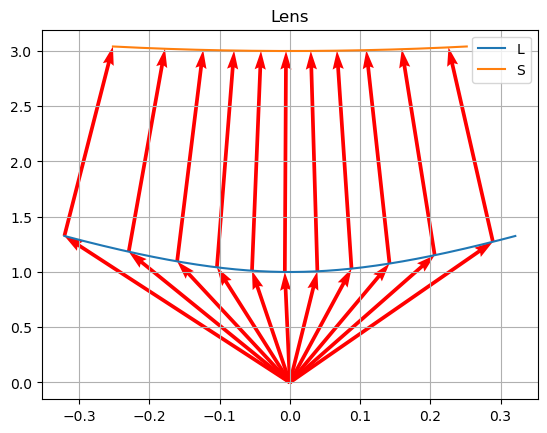

In [49]:
step = 29
xr_vectors = xrho[::step]
m_vectors  = M_array[::step]
d_vectors  = d_array[::step]

plt.figure()
plt.plot(xrho[:,0],xrho[:,1], label = 'L')
plt.plot(F_array[:,0],F_array[:,1], label = 'S')


for i in np.arange(dinterval[::step].size):
    plt.quiver(0, 0, xr_vectors[i,0], xr_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red')
    plt.quiver(xr_vectors[i,0], xr_vectors[i,1], d_vectors[i] * m_vectors[i, 0], d_vectors[i] * m_vectors[i, 1], angles='xy', scale_units='xy', scale=1, color='red')


plt.legend()
plt.title("Lens")
plt.grid(True)
plt.plot